<a href="https://colab.research.google.com/github/HLima214/Treinamento_IA---Modelo-XGBoost/blob/main/Treinamento_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Treinamento de um modelo para regressão usando XGBoost


In [ ]:
import pandas as pd

In [ ]:
#Leitura do dataset

df = pd.read_csv('/content/casas_california.csv')

df

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_imoveis,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
df.columns

Index(['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'total_quartos', 'populacao', 'domicilios', 'renda_mediana',
       'valor_mediano_imoveis', 'proximidade_oceano'],
      dtype='object')

In [ ]:
#Transformando variáveis não númericas em numéricas

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

df['proximidade_oceano'] = le.fit_transform(df['proximidade_oceano'])

df

#Normalização dos dados
scaler = StandardScaler()

colunas_numericas = ['longitude', 'latitude', 'idade_mediana_imoveis', 'total_comodos',
       'total_quartos', 'populacao', 'domicilios', 'renda_mediana']

df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])

#Preparação dos dados de entrada e sáida

input = df.drop('valor_mediano_imoveis', axis=1)
output = df['valor_mediano_imoveis']

#Preparação dos dados de treino e teste
xtreino, xteste, ytreino, yteste = train_test_split(input, output, test_size=0.3, random_state=42)

print(xtreino.shape)
print(xteste.shape)
print(ytreino.shape)
print(ytreino.shape)


(14448, 9)
(6192, 9)
(14448,)
(14448,)


In [ ]:
xtreino

,longitude,latitude,idade_mediana_imoveis,total_comodos,total_quartos,populacao,domicilios,renda_mediana,proximidade_oceano
7061,0.773505,-0.796789,0.505394,-0.108071,-0.331939,-0.183213,-0.239432,0.137137,0
14689,1.237697,-1.330521,-0.686477,-0.207541,-0.009186,-0.376602,-0.009258,-0.530363,4
17323,-0.284652,-0.487786,-0.368645,-0.474322,-0.607228,-0.613260,-0.561151,0.174720,4
10056,-0.713904,1.698646,-1.163225,-0.836906,-0.918115,-0.992090,-0.945646,-0.400716,1
15750,-1.437644,1.001048,1.856182,0.253138,0.403749,0.088767,0.430163,-0.296809,3
...,...,...,...,...,...,...,...,...,...
11284,0.803453,-0.867017,0.505394,-0.598545,-0.799456,-0.677723,-0.739013,1.315592,0
11964,1.067992,-0.754652,0.346478,0.205466,0.076249,0.289220,-0.132192,-0.431983,1
5390,0.593818,-0.749970,0.584852,-0.245128,0.073876,0.291870,0.071825,-0.492832,0
860,-1.193070,0.912092,-1.083767,0.430534,0.140325,0.310414,0.155525,0.973025,0


In [ ]:
#Parâmetros do modelo (XGBoost)
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score


modelo_xgb = XGBRegressor(
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

modelo_xgb.fit(xtreino, ytreino)

#Avaliação do modelo (MAPE e R2)

#Previsão para os dados de treino e teste
ytreino_pred = modelo_xgb.predict(xtreino)
yteste_pred = modelo_xgb.predict(xteste)

ytreino_pred

#Métricas de desempenho
mape_treino = mean_absolute_percentage_error(ytreino, ytreino_pred)
mape_teste = mean_absolute_percentage_error(yteste, yteste_pred)

r2_treino = r2_score(ytreino, ytreino_pred)
r2_teste = r2_score(yteste, yteste_pred)

#Estrutura de sáida
print(f"MAPE (TREINO): {mape_treino * 100}")
print(f"MAPE (TESTE): {mape_teste * 100}")

print(f"MAPE (TREINO): {r2_treino * 100}")
print(f"MAPE (TESTE): {r2_teste * 100}")

MAPE (TREINO): 18.738952381770012
MAPE (TESTE): 20.8897365492943
MAPE (TREINO): 82.70247475535474
MAPE (TESTE): 78.85035871371136


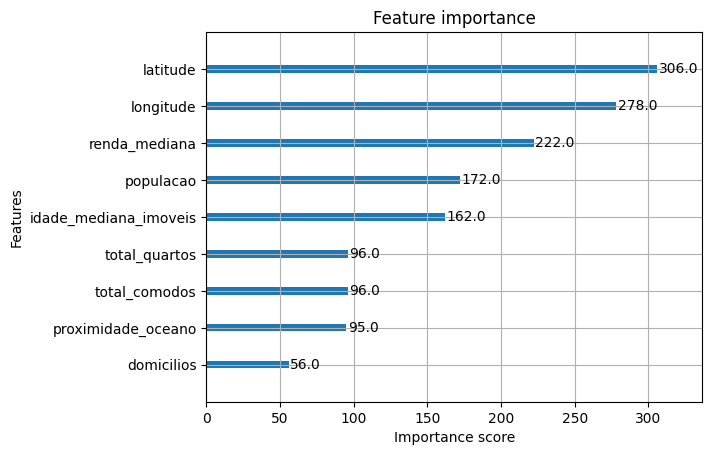

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(modelo_xgb)
plt.show()

In [ ]:
ytreino

,valor_mediano_imoveis
7061,193800.0
14689,169700.0
17323,259800.0
10056,136100.0
15750,500001.0
...,...
11284,229200.0
11964,97800.0
5390,222100.0
860,283500.0
